In [1]:
!pip install pytorch-msssim

In [1]:

import os
import glob
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from PIL import Image as PILImage
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from google.colab import drive
from pytorch_msssim import SSIM
import matplotlib.pyplot as plt
import random
from IPython.display import Image, display

In [2]:
# Mount Google Drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
import cv2
import numpy as np
import time


In [4]:
base_path = '/content/FER'  # change if needed
splits = ['Train', 'Validate', 'Test']

In [5]:
sigma = 5
image_size = (48, 48)
noise_folder_name = f'noisy_sigma{sigma}'

In [7]:
gdrive_base_path = '/content/drive/MyDrive/FER'
import shutil, os, time
if not os.path.exists(base_path):
    print("📂 Copying dataset to local disk...")
    start_time = time.time()
    shutil.copytree(gdrive_base_path, base_path)
    print(f"✅ Dataset copied to {base_path} in {time.time() - start_time:.2f} seconds")

📂 Copying dataset to local disk...
✅ Dataset copied to /content/FER in 847.54 seconds


In [6]:
print("🚀 Starting Gaussian noise generation...")

start_time = time.time()
total_images = 0

for split in splits:
    split_path = os.path.join(base_path, split)
    noisy_path = os.path.join(split_path, noise_folder_name)

    if not os.path.exists(split_path):
        print(f"⚠️ Skipping missing split: {split}")
        continue

    os.makedirs(noisy_path, exist_ok=True)
    print(f"\n📂 Processing {split} → {noise_folder_name}")

    for img_name in os.listdir(split_path):

        img_path = os.path.join(split_path, img_name)

        # Skip folders (like noisy_sigma15)
        if os.path.isdir(img_path):
            continue

        # Read grayscale image
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        img = cv2.resize(img, image_size)

        # Gaussian Noise
        noise = np.random.normal(0, sigma, img.shape)
        noisy_img = img.astype(np.float32) + noise
        noisy_img = np.clip(noisy_img, 0, 255).astype(np.uint8)

        # Save noisy image with SAME NAME
        cv2.imwrite(os.path.join(noisy_path, img_name), noisy_img)
        total_images += 1

    print(f"✅ Done: {split}")


🚀 Starting Gaussian noise generation...

📂 Processing Train → noisy_sigma5
✅ Done: Train

📂 Processing Validate → noisy_sigma5
✅ Done: Validate

📂 Processing Test → noisy_sigma5
✅ Done: Test


In [7]:
print("\n🎉 Noise generation complete")
print(f"🖼️ Total images processed: {total_images}")
print(f"⏱️ Time taken: {time.time() - start_time:.2f} seconds")


🎉 Noise generation complete
🖼️ Total images processed: 13334
⏱️ Time taken: 7.15 seconds


In [8]:
local_base = "/content/FER"
drive_base = "/content/drive/MyDrive/FER"
splits = ["Train", "Validate", "Test"]
sigma = 5

for split in splits:
    src = os.path.join(local_base, split, f"noisy_sigma{sigma}")
    dst = os.path.join(drive_base, split, f"noisy_sigma{sigma}")

    if not os.path.exists(src):
        print(f"⚠️ Missing source: {src}")
        continue

    if os.path.exists(dst):
        shutil.rmtree(dst)  # overwrite safely

    shutil.copytree(src, dst)
    print(f"✅ Copied {src} → {dst}")

NameError: name 'shutil' is not defined

In [9]:
sigma = 5
image_size = (48, 48)
noise_folder_name = f'noisy_sigma{sigma}'

In [10]:
test_path = os.path.join(local_base, "Test")

if not os.path.exists(test_path):
    raise FileNotFoundError(f"Test folder not found: {test_path}")

noisy_path = os.path.join(test_path, f"noisy_sigma{sigma}")

if not os.path.exists(noisy_path):
    raise FileNotFoundError(f"Noisy folder not found: {noisy_path}")

print(f"📂 Found test folder: {test_path}")
print(f"📂 Found noisy folder: {noisy_path}")

📂 Found test folder: /content/FER/Test
📂 Found noisy folder: /content/FER/Test/noisy_sigma5


In [11]:
# Dataset class (same as original)
class PairedNoisyCleanDataset(Dataset):
    def __init__(self, base_dir, split, transform=None):
        self.transform = transform
        split_dir = os.path.join(base_dir, split.capitalize())
        noisy_dir = os.path.join(split_dir, f'noisy_sigma{sigma}')
        self.clean_images = []
        for root, _, files in os.walk(split_dir):
            if os.path.abspath(root) == os.path.abspath(noisy_dir):
                continue
            for f in files:
                if f.lower().endswith('.jpg'):
                    self.clean_images.append(os.path.join(root, f))
        self.noisy_images = [
            os.path.join(noisy_dir, f) for f in os.listdir(noisy_dir)
            if f.lower().endswith('.jpg')
        ]
        clean_dict = {os.path.basename(p): p for p in self.clean_images}
        noisy_dict = {os.path.basename(p): p for p in self.noisy_images}
        self.matched_clean = []
        self.matched_noisy = []
        for fname in noisy_dict:
            if fname in clean_dict:
                self.matched_clean.append(clean_dict[fname])
                self.matched_noisy.append(noisy_dict[fname])
        print(f"📊 [test] Found {len(self.matched_clean)} paired samples")

    def __len__(self):
        return len(self.matched_clean)

    def __getitem__(self, idx):
        noisy_img = PILImage.open(self.matched_noisy[idx]).convert('L')
        clean_img = PILImage.open(self.matched_clean[idx]).convert('L')
        if self.transform:
            seed = torch.randint(0, 2**31, (1,)).item()
            torch.manual_seed(seed)
            noisy_img = self.transform(noisy_img)
            torch.manual_seed(seed)
            clean_img = self.transform(clean_img)
        return noisy_img, clean_img, self.matched_noisy[idx]

In [12]:

# Transforms (same as original)
val_test_transform = transforms.ToTensor()

# Test Dataset and DataLoader
batch_size = 16
test_dataset = PairedNoisyCleanDataset(local_base, 'test', val_test_transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
print(f"Test dataset size: {len(test_dataset)}")

📊 [test] Found 2148 paired samples
Test dataset size: 2148


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


In [13]:
# Model definition (same as original)
class MultiScaleEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.branch3x3 = nn.Sequential(
            nn.Conv2d(1, 126, kernel_size=3, padding=1),
            nn.BatchNorm2d(126),
            nn.ReLU(inplace=True),
            nn.Conv2d(126, 126, kernel_size=3, padding=1),
            nn.BatchNorm2d(126),
            nn.ReLU(inplace=True)
        )
        self.branch5x5 = nn.Sequential(
            nn.Conv2d(1, 126, kernel_size=5, padding=2),
            nn.BatchNorm2d(126),
            nn.ReLU(inplace=True),
            nn.Conv2d(126, 126, kernel_size=5, padding=2),
            nn.BatchNorm2d(126),
            nn.ReLU(inplace=True)
        )
        self.residual = nn.Conv2d(1, 252, kernel_size=1)

    def forward(self, x):
        f1 = self.branch3x3(x)
        f2 = self.branch5x5(x)
        res = self.residual(x)
        return torch.cat([f1, f2], dim=1) + res

class NoiseGateModule(nn.Module):
    def __init__(self, in_channels=252):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, 1, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        mask = self.conv(x)
        mask = self.sigmoid(mask)
        return x * mask

class ChannelAttentionBlock(nn.Module):
    def __init__(self, in_channels=252):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.conv = nn.Conv2d(in_channels * 2, in_channels, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.avg_pool(x)
        max_out = self.max_pool(x)
        pooled = torch.cat([avg_out, max_out], dim=1)
        attn = self.conv(pooled)
        attn = self.sigmoid(attn)
        return x * attn

class DualHeadDecoder(nn.Module):
    def __init__(self, in_channels=252):
        super().__init__()
        self.structural_head = nn.Sequential(
            nn.Conv2d(in_channels, 126, kernel_size=3, padding=1),
            nn.BatchNorm2d(126),
            nn.ReLU(inplace=True),
            nn.Conv2d(126, 63, kernel_size=3, padding=1),
            nn.BatchNorm2d(63),
            nn.ReLU(inplace=True),
            nn.Conv2d(63, 33, kernel_size=3, padding=1),
            nn.BatchNorm2d(33),
            nn.ReLU(inplace=True),
            nn.Conv2d(33, 15, kernel_size=3, padding=1),
            nn.BatchNorm2d(15),
            nn.ReLU(inplace=True),
            nn.Conv2d(15, 1, kernel_size=3, padding=1),
            nn.BatchNorm2d(1)
        )
        self.texture_head = nn.Sequential(
            nn.Conv2d(in_channels, 126, kernel_size=5, padding=2),
            nn.BatchNorm2d(126),
            nn.ReLU(inplace=True),
            nn.Conv2d(126, 63, kernel_size=5, padding=2),
            nn.BatchNorm2d(63),
            nn.ReLU(inplace=True),
            nn.Conv2d(63, 33, kernel_size=5, padding=2),
            nn.BatchNorm2d(33),
            nn.ReLU(inplace=True),
            nn.Conv2d(33, 15, kernel_size=5, padding=2),
            nn.BatchNorm2d(15),
            nn.ReLU(inplace=True),
            nn.Conv2d(15, 1, kernel_size=5, padding=2),
            nn.BatchNorm2d(1)
        )
        self.alpha = nn.Parameter(torch.tensor(0.6))

    def forward(self, x):
        struct = self.structural_head(x)
        text = self.texture_head(x)
        return self.alpha * struct + (1 - self.alpha) * text

class SharpeningModule(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(1, 1, kernel_size=3, padding=1, bias=False)
        laplacian = torch.tensor([[[[0, -1, 0], [-1, 4, -1], [0, -1, 0]]]], dtype=torch.float32)
        self.conv.weight = nn.Parameter(laplacian)
        self.strength = nn.Parameter(torch.tensor(0.7))

    def forward(self, x):
        edges = self.conv(x)
        return x + self.strength * edges

class BiMSAAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = MultiScaleEncoder()
        self.noise_gate = NoiseGateModule()
        self.attention = ChannelAttentionBlock()
        self.decoder = DualHeadDecoder()
        self.sharpen = SharpeningModule()
        self.skip_conv = nn.Conv2d(252, 252, kernel_size=1)

    def forward(self, x):
        f = self.encoder(x)
        skip = self.skip_conv(f)
        f = self.noise_gate(f)
        f = self.attention(f)
        f = f + skip
        out = self.decoder(f)
        out = torch.sigmoid(out)
        out = self.sharpen(out)
        return torch.clamp(out, 0, 1)


In [14]:
# Loss Functions (only needed for loss computation if desired)
class PerceptualLoss(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = models.vgg16(pretrained=True).features[:9].eval()
        for param in vgg.parameters():
            param.requires_grad = False
        self.vgg = vgg.to(dtype=torch.float32)
        self.mse = nn.MSELoss()

    def forward(self, output, target):
        output = output.repeat(1, 3, 1, 1).to(dtype=torch.float32)
        target = target.repeat(1, 3, 1, 1).to(dtype=torch.float32)
        output_vgg = self.vgg(output)
        target_vgg = self.vgg(target)
        return self.mse(output_vgg, target_vgg)

class EdgeLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.sobel_x = torch.tensor([[[[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]]], dtype=torch.float32)
        self.sobel_y = torch.tensor([[[[-1, -2, -1], [0, 0, 0], [1, 2, 1]]]], dtype=torch.float32)
        self.mse = nn.MSELoss()

    def forward(self, output, target):
        self.sobel_x = self.sobel_x.to(output.device)
        self.sobel_y = self.sobel_y.to(output.device)
        grad_x_out = F.conv2d(output, self.sobel_x)
        grad_y_out = F.conv2d(output, self.sobel_y)
        grad_x_tgt = F.conv2d(target, self.sobel_x)
        grad_y_tgt = F.conv2d(target, self.sobel_y)
        return self.mse(grad_x_out, grad_x_tgt) + self.mse(grad_y_out, grad_y_tgt)

In [15]:
# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Create NEW model (no checkpoints)
model = BiMSAAE().to(device)

# Loss functions
mse_criterion = nn.MSELoss()
perceptual_criterion = PerceptualLoss().to(device)
ssim_criterion = SSIM(data_range=1.0, channel=1, win_size=7).to(device)
edge_criterion = EdgeLoss().to(device)

# Set mode
model.eval()

print("🆕 New BiMSAAE model initialized (no checkpoints loaded)")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


🆕 New BiMSAAE model initialized (no checkpoints loaded)


In [20]:
# Install dependencies
!pip install torch==2.3.0 torchvision==0.18.0 torchaudio==2.3.0 --index-url https://download.pytorch.org/whl/cu121
!pip install pytorch-msssim scikit-image matplotlib
!apt-get install -y ffmpeg

Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.9/780.9 MB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 63.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 122.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 98.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 64.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 138.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 838.9 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 8.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 13.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 8.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/19

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.


In [17]:
import os

# Define dataset paths
local_base_path = '/content/FER'  # your local dataset folder
splits = {
    'train': os.path.join(local_base_path, 'Train'),
    'validate': os.path.join(local_base_path, 'Validate'),
    'test': os.path.join(local_base_path, 'Test')
}

# Noise level for new dataset
sigma = 25  # Gaussian noise sigma for training
image_size = (48, 48)  # resize images to 48x48 if needed

# Output directories
output_dir = '/content/drive/MyDrive/denoising_samples'  # for saving denoised images
new_checkpoint_dir = '/content/drive/MyDrive/bimsaae_checkpoints_new5'  # new checkpoint folder

# Ensure output folders exist
os.makedirs(output_dir, exist_ok=True)
os.makedirs(new_checkpoint_dir, exist_ok=True)

# Optional: create noisy folders in train/validate/test if not exist
for split in splits:
    noisy_folder = os.path.join(splits[split], f'noisy_sigma{sigma}')
    os.makedirs(noisy_folder, exist_ok=True)
    print(f"📂 Ready folder for {split} with sigma {sigma}: {noisy_folder}")

print(f"✅ Output directory: {output_dir}")
print(f"✅ New checkpoint directory: {new_checkpoint_dir}")

📂 Ready folder for train with sigma 25: /content/FER/Train/noisy_sigma25
📂 Ready folder for validate with sigma 25: /content/FER/Validate/noisy_sigma25
📂 Ready folder for test with sigma 25: /content/FER/Test/noisy_sigma25
✅ Output directory: /content/drive/MyDrive/denoising_samples
✅ New checkpoint directory: /content/drive/MyDrive/bimsaae_checkpoints_new5


In [18]:
import os
import glob
from PIL import Image as PILImage

In [19]:
# Verify folder existence and image sizes
for split, path in splits.items():
    if not os.path.exists(path):
        raise FileNotFoundError(f"Folder not found: {path}")
    noisy_path = os.path.join(path, f'noisy_sigma{sigma}')
    if not os.path.exists(noisy_path):
        raise FileNotFoundError(f"Noisy folder not found: {noisy_path}")
    print(f"📂 Found {split} folder: {path}")
    sample_files = glob.glob(os.path.join(noisy_path, '*.jpg'))
    if sample_files:
        sample_img = PILImage.open(sample_files[0]).convert('L')
        if sample_img.size != image_size:
            raise ValueError(f"Expected 128x128 images, found {sample_img.size} in {noisy_path}")

📂 Found train folder: /content/FER/Train
📂 Found validate folder: /content/FER/Validate
📂 Found test folder: /content/FER/Test


In [20]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image as PILImage

In [21]:
# Dataset class for grayscale JPG
class PairedNoisyCleanDataset(Dataset):
    def __init__(self, base_dir, split, transform=None):
        self.transform = transform
        split_dir = os.path.join(base_dir, split.capitalize())
        noisy_dir = os.path.join(split_dir, f'noisy_sigma{sigma}')
        self.clean_images = []
        for root, _, files in os.walk(split_dir):
            if os.path.abspath(root) == os.path.abspath(noisy_dir):
                continue
            for f in files:
                if f.lower().endswith('.jpg'):
                    self.clean_images.append(os.path.join(root, f))
        self.noisy_images = [
            os.path.join(noisy_dir, f) for f in os.listdir(noisy_dir)
            if f.lower().endswith('.jpg')
        ]
        clean_dict = {os.path.basename(p): p for p in self.clean_images}
        noisy_dict = {os.path.basename(p): p for p in self.noisy_images}
        self.matched_clean = []
        self.matched_noisy = []
        for fname in noisy_dict:
            if fname in clean_dict:
                self.matched_clean.append(clean_dict[fname])
                self.matched_noisy.append(noisy_dict[fname])
        print(f"📊 [{split}] Found {len(self.matched_clean)} paired samples")

    def __len__(self):
        return len(self.matched_clean)

    def __getitem__(self, idx):
        noisy_img = PILImage.open(self.matched_noisy[idx]).convert('L')
        clean_img = PILImage.open(self.matched_clean[idx]).convert('L')
        if self.transform:
            seed = torch.randint(0, 2**31, (1,)).item()
            torch.manual_seed(seed)
            noisy_img = self.transform(noisy_img)
            torch.manual_seed(seed)
            clean_img = self.transform(clean_img)
        return noisy_img, clean_img, self.matched_noisy[idx]

# Transforms
train_transform = transforms.Compose([
    transforms.RandomCrop(48),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ToTensor()
])
val_test_transform = transforms.ToTensor()

In [22]:
import os
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

# --- Noise level ---
sigma = 5  # new noise level

# --- Dataset transforms ---
train_transform = transforms.Compose([
    transforms.RandomCrop(48),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ToTensor()
])
val_test_transform = transforms.ToTensor()

# --- Dataset paths ---
local_base_path = '/content/FER'

# --- Datasets ---
train_dataset = PairedNoisyCleanDataset(local_base_path, 'train', train_transform)
val_dataset = PairedNoisyCleanDataset(local_base_path, 'validate', val_test_transform)
test_dataset = PairedNoisyCleanDataset(local_base_path, 'test', val_test_transform)

# --- DataLoaders ---
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

📊 [train] Found 8528 paired samples
📊 [validate] Found 2658 paired samples
📊 [test] Found 2148 paired samples
Train dataset size: 8528
Validation dataset size: 2658
Test dataset size: 2148


In [23]:
import torch
import torch.nn as nn

In [24]:
# Bi-MSAAE Model for grayscale
class MultiScaleEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.branch3x3 = nn.Sequential(
            nn.Conv2d(1, 126, kernel_size=3, padding=1),
            nn.BatchNorm2d(126),
            nn.ReLU(inplace=True),
            nn.Conv2d(126, 126, kernel_size=3, padding=1),
            nn.BatchNorm2d(126),
            nn.ReLU(inplace=True)
        )
        self.branch5x5 = nn.Sequential(
            nn.Conv2d(1, 126, kernel_size=5, padding=2),
            nn.BatchNorm2d(126),
            nn.ReLU(inplace=True),
            nn.Conv2d(126, 126, kernel_size=5, padding=2),
            nn.BatchNorm2d(126),
            nn.ReLU(inplace=True)
        )
        self.residual = nn.Conv2d(1, 252, kernel_size=1)

    def forward(self, x):
        f1 = self.branch3x3(x)
        f2 = self.branch5x5(x)
        res = self.residual(x)
        return torch.cat([f1, f2], dim=1) + res

class NoiseGateModule(nn.Module):
    def __init__(self, in_channels=252):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, 1, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        mask = self.conv(x)
        mask = self.sigmoid(mask)
        return x * mask

class ChannelAttentionBlock(nn.Module):
    def __init__(self, in_channels=252):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.conv = nn.Conv2d(in_channels * 2, in_channels, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.avg_pool(x)
        max_out = self.max_pool(x)
        pooled = torch.cat([avg_out, max_out], dim=1)
        attn = self.conv(pooled)
        attn = self.sigmoid(attn)
        return x * attn

class DualHeadDecoder(nn.Module):
    def __init__(self, in_channels=252):
        super().__init__()
        self.structural_head = nn.Sequential(
            nn.Conv2d(in_channels, 126, kernel_size=3, padding=1),
            nn.BatchNorm2d(126),
            nn.ReLU(inplace=True),
            nn.Conv2d(126, 63, kernel_size=3, padding=1),
            nn.BatchNorm2d(63),
            nn.ReLU(inplace=True),
            nn.Conv2d(63, 33, kernel_size=3, padding=1),
            nn.BatchNorm2d(33),
            nn.ReLU(inplace=True),
            nn.Conv2d(33, 15, kernel_size=3, padding=1),
            nn.BatchNorm2d(15),
            nn.ReLU(inplace=True),
            nn.Conv2d(15, 1, kernel_size=3, padding=1),
            nn.BatchNorm2d(1)
        )
        self.texture_head = nn.Sequential(
            nn.Conv2d(in_channels, 126, kernel_size=5, padding=2),
            nn.BatchNorm2d(126),
            nn.ReLU(inplace=True),
            nn.Conv2d(126, 63, kernel_size=5, padding=2),
            nn.BatchNorm2d(63),
            nn.ReLU(inplace=True),
            nn.Conv2d(63, 33, kernel_size=5, padding=2),
            nn.BatchNorm2d(33),
            nn.ReLU(inplace=True),
            nn.Conv2d(33, 15, kernel_size=5, padding=2),
            nn.BatchNorm2d(15),
            nn.ReLU(inplace=True),
            nn.Conv2d(15, 1, kernel_size=5, padding=2),
            nn.BatchNorm2d(1)
        )
        self.alpha = nn.Parameter(torch.tensor(0.6))

    def forward(self, x):
        struct = self.structural_head(x)
        text = self.texture_head(x)
        return self.alpha * struct + (1 - self.alpha) * text

class SharpeningModule(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(1, 1, kernel_size=3, padding=1, bias=False)
        laplacian = torch.tensor([[[[0, -1, 0], [-1, 4, -1], [0, -1, 0]]]], dtype=torch.float32)
        self.conv.weight = nn.Parameter(laplacian)
        self.strength = nn.Parameter(torch.tensor(0.7))

    def forward(self, x):
        edges = self.conv(x)
        return x + self.strength * edges

class BiMSAAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = MultiScaleEncoder()
        self.noise_gate = NoiseGateModule()
        self.attention = ChannelAttentionBlock()
        self.decoder = DualHeadDecoder()
        self.sharpen = SharpeningModule()
        self.skip_conv = nn.Conv2d(252, 252, kernel_size=1)

    def forward(self, x):
        f = self.encoder(x)
        skip = self.skip_conv(f)
        f = self.noise_gate(f)
        f = self.attention(f)
        f = f + skip
        out = self.decoder(f)
        out = torch.sigmoid(out)
        out = self.sharpen(out)
        return torch.clamp(out, 0, 1)

In [25]:
# Loss Functions
class PerceptualLoss(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = models.vgg16(pretrained=True).features[:9].eval()
        for param in vgg.parameters():
            param.requires_grad = False
        self.vgg = vgg.to(dtype=torch.float32)
        self.mse = nn.MSELoss()

    def forward(self, output, target):
        output = output.repeat(1, 3, 1, 1).to(dtype=torch.float32)
        target = target.repeat(1, 3, 1, 1).to(dtype=torch.float32)
        output_vgg = self.vgg(output)
        target_vgg = self.vgg(target)
        return self.mse(output_vgg, target_vgg)

class EdgeLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.sobel_x = torch.tensor([[[[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]]], dtype=torch.float32)
        self.sobel_y = torch.tensor([[[[-1, -2, -1], [0, 0, 0], [1, 2, 1]]]], dtype=torch.float32)
        self.mse = nn.MSELoss()

    def forward(self, output, target):
        self.sobel_x = self.sobel_x.to(output.device)
        self.sobel_y = self.sobel_y.to(output.device)
        grad_x_out = F.conv2d(output, self.sobel_x)
        grad_y_out = F.conv2d(output, self.sobel_y)
        grad_x_tgt = F.conv2d(target, self.sobel_x)
        grad_y_tgt = F.conv2d(target, self.sobel_y)
        return self.mse(grad_x_out, grad_x_tgt) + self.mse(grad_y_out, grad_y_tgt)

In [26]:
# Training function
def train_model(model, train_loader, val_loader, mse_criterion, perceptual_criterion, ssim_criterion, edge_criterion, optimizer, scheduler, device, num_epochs, warmup_epochs=5, start_epoch=0):
    model.to(device)
    best_psnr = 0.0
    best_model_path = os.path.join(drive_checkpoint_dir, 'bimsaae_best.pth')
    for epoch in range(start_epoch, num_epochs):
        start_time = time.time()
        model.train()
        train_loss = 0.0
        lr = optimizer.param_groups[0]['lr']
        if epoch < warmup_epochs:
            lr_factor = (epoch + 1) / warmup_epochs
            for param_group in optimizer.param_groups:
                param_group['lr'] = lr * lr_factor
        optimizer.zero_grad()
        for noisy, clean, _ in train_loader:
            noisy, clean = noisy.to(device), clean.to(device)
            outputs = model(noisy)
            mse_loss = mse_criterion(outputs, clean)
            perceptual_loss = perceptual_criterion(outputs, clean)
            ssim_loss = 1 - ssim_criterion(outputs, clean)
            edge_loss = edge_criterion(outputs, clean)
            loss = 0.5 * mse_loss + 0.3 * perceptual_loss + 0.1 * ssim_loss + 0.1 * edge_loss
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            train_loss += loss.item() * noisy.size(0)
        model.eval()
        val_loss, psnr_val, ssim_val = 0.0, 0.0, 0.0
        with torch.no_grad():
            for noisy, clean, _ in val_loader:
                noisy, clean = noisy.to(device), clean.to(device)
                outputs = model(noisy)
                mse_loss = mse_criterion(outputs, clean)
                perceptual_loss = perceptual_criterion(outputs, clean)
                ssim_loss = 1 - ssim_criterion(outputs, clean)
                edge_loss = edge_criterion(outputs, clean)
                loss = 0.5 * mse_loss + 0.3 * perceptual_loss + 0.1 * ssim_loss + 0.1 * edge_loss
                val_loss += loss.item() * noisy.size(0)
                outputs_np = outputs.cpu().numpy()
                clean_np = clean.cpu().numpy()
                for i in range(outputs_np.shape[0]):
                    psnr_val += peak_signal_noise_ratio(clean_np[i, 0], outputs_np[i, 0], data_range=1.0)
                    ssim_val += structural_similarity(clean_np[i, 0], outputs_np[i, 0], data_range=1.0, win_size=7)
        val_loss /= len(val_dataset)
        psnr_val /= len(val_dataset)
        ssim_val /= len(val_dataset)
        avg_train_loss = train_loss / len(train_dataset)
        epoch_time = time.time() - start_time
        current_lr = optimizer.param_groups[0]['lr']
        if epoch >= warmup_epochs:
            scheduler.step()
        print(f"\r\033[96mEpoch {epoch+1}/{num_epochs} [{100*(epoch+1)/num_epochs:.1f}%]\033[0m")
        print(f"🌟 Train Loss: {avg_train_loss:.6f} | Val Loss: {val_loss:.6f} | PSNR: {psnr_val:.2f} dB | SSIM: {ssim_val:.4f} | Time: {epoch_time:.2f}s | LR: {current_lr:.6e}")
        checkpoint_path = os.path.join(drive_checkpoint_dir, f'bimsaae_epoch_{epoch+1}.pth')
        torch.save(model.state_dict(), checkpoint_path)
        print(f"💾 Checkpoint saved to {checkpoint_path}")
        if psnr_val > best_psnr:
            best_psnr = psnr_val
            torch.save(model.state_dict(), best_model_path)
            print(f"🏆 New best model saved to {best_model_path} (PSNR: {psnr_val:.2f})")
        if psnr_val > 35 and ssim_val > 0.95 and epoch >= 20:
            print(f"🎯 Target metrics achieved at epoch {epoch+1}. Stopping training.")
            break


In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms

In [28]:
from torch.utils.data import Dataset, DataLoader
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from PIL import Image as PILImage
import os
import time

In [29]:
!pip install pytorch-msssim

In [30]:
from pytorch_msssim import ssim as SSIM

In [31]:
# ----------------------------
# 1. Imports
# ----------------------------
import os
import time
import glob
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image as PILImage
from pytorch_msssim import ssim
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

# ----------------------------
# 2. Dataset Paths and Noise Level
# ----------------------------
local_base_path = '/content/FER'  # change if different
sigma = 25  # new noise level
output_dir = '/content/denoising_samples'
checkpoint_dir = '/content/bimsaae_checkpoints'

os.makedirs(output_dir, exist_ok=True)
os.makedirs(checkpoint_dir, exist_ok=True)

splits = {
    'train': os.path.join(local_base_path, 'Train'),
    'validate': os.path.join(local_base_path, 'Validate'),
    'test': os.path.join(local_base_path, 'Test')
}

# ----------------------------
# 3. Dataset Class
# ----------------------------
class PairedNoisyCleanDataset(Dataset):
    def __init__(self, base_dir, split, transform=None):
        self.transform = transform
        split_dir = os.path.join(base_dir, split.capitalize())
        noisy_dir = os.path.join(split_dir, f'noisy_sigma{sigma}')
        self.clean_images = []
        for root, _, files in os.walk(split_dir):
            if os.path.abspath(root) == os.path.abspath(noisy_dir):
                continue
            for f in files:
                if f.lower().endswith('.jpg'):
                    self.clean_images.append(os.path.join(root, f))
        self.noisy_images = [
            os.path.join(noisy_dir, f) for f in os.listdir(noisy_dir)
            if f.lower().endswith('.jpg')
        ]
        clean_dict = {os.path.basename(p): p for p in self.clean_images}
        noisy_dict = {os.path.basename(p): p for p in self.noisy_images}
        self.matched_clean = []
        self.matched_noisy = []
        for fname in noisy_dict:
            if fname in clean_dict:
                self.matched_clean.append(clean_dict[fname])
                self.matched_noisy.append(noisy_dict[fname])
        print(f"📊 [{split}] Found {len(self.matched_clean)} paired samples")

    def __len__(self):
        return len(self.matched_clean)

    def __getitem__(self, idx):
        noisy_img = PILImage.open(self.matched_noisy[idx]).convert('L')
        clean_img = PILImage.open(self.matched_clean[idx]).convert('L')
        if self.transform:
            seed = torch.randint(0, 2**31, (1,)).item()
            torch.manual_seed(seed)
            noisy_img = self.transform(noisy_img)
            torch.manual_seed(seed)
            clean_img = self.transform(clean_img)
        return noisy_img, clean_img, self.matched_noisy[idx]

# ----------------------------
# 4. Transforms
# ----------------------------
train_transform = transforms.Compose([
    transforms.RandomCrop(48),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ToTensor()
])
val_test_transform = transforms.ToTensor()

# ----------------------------
# 5. DataLoaders
# ----------------------------
batch_size = 16
train_dataset = PairedNoisyCleanDataset(local_base_path, 'train', train_transform)
val_dataset = PairedNoisyCleanDataset(local_base_path, 'validate', val_test_transform)
test_dataset = PairedNoisyCleanDataset(local_base_path, 'test', val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

# ----------------------------
# 6. Bi-MSAAE Model Definition
# ----------------------------
class MultiScaleEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.branch3x3 = nn.Sequential(
            nn.Conv2d(1, 126, kernel_size=3, padding=1),
            nn.BatchNorm2d(126),
            nn.ReLU(inplace=True),
            nn.Conv2d(126, 126, kernel_size=3, padding=1),
            nn.BatchNorm2d(126),
            nn.ReLU(inplace=True)
        )
        self.branch5x5 = nn.Sequential(
            nn.Conv2d(1, 126, kernel_size=5, padding=2),
            nn.BatchNorm2d(126),
            nn.ReLU(inplace=True),
            nn.Conv2d(126, 126, kernel_size=5, padding=2),
            nn.BatchNorm2d(126),
            nn.ReLU(inplace=True)
        )
        self.residual = nn.Conv2d(1, 252, kernel_size=1)

    def forward(self, x):
        f1 = self.branch3x3(x)
        f2 = self.branch5x5(x)
        res = self.residual(x)
        return torch.cat([f1, f2], dim=1) + res

class NoiseGateModule(nn.Module):
    def __init__(self, in_channels=252):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, 1, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        mask = self.conv(x)
        mask = self.sigmoid(mask)
        return x * mask

class ChannelAttentionBlock(nn.Module):
    def __init__(self, in_channels=252):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.conv = nn.Conv2d(in_channels*2, in_channels, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.avg_pool(x)
        max_out = self.max_pool(x)
        pooled = torch.cat([avg_out, max_out], dim=1)
        attn = self.conv(pooled)
        attn = self.sigmoid(attn)
        return x * attn

class DualHeadDecoder(nn.Module):
    def __init__(self, in_channels=252):
        super().__init__()
        # Structural and texture heads (same as before)
        self.structural_head = nn.Sequential(
            nn.Conv2d(in_channels, 126, kernel_size=3, padding=1),
            nn.BatchNorm2d(126),
            nn.ReLU(inplace=True),
            nn.Conv2d(126, 63, kernel_size=3, padding=1),
            nn.BatchNorm2d(63),
            nn.ReLU(inplace=True),
            nn.Conv2d(63, 33, kernel_size=3, padding=1),
            nn.BatchNorm2d(33),
            nn.ReLU(inplace=True),
            nn.Conv2d(33, 15, kernel_size=3, padding=1),
            nn.BatchNorm2d(15),
            nn.ReLU(inplace=True),
            nn.Conv2d(15, 1, kernel_size=3, padding=1),
            nn.BatchNorm2d(1)
        )
        self.texture_head = nn.Sequential(
            nn.Conv2d(in_channels, 126, kernel_size=5, padding=2),
            nn.BatchNorm2d(126),
            nn.ReLU(inplace=True),
            nn.Conv2d(126, 63, kernel_size=5, padding=2),
            nn.BatchNorm2d(63),
            nn.ReLU(inplace=True),
            nn.Conv2d(63, 33, kernel_size=5, padding=2),
            nn.BatchNorm2d(33),
            nn.ReLU(inplace=True),
            nn.Conv2d(33, 15, kernel_size=5, padding=2),
            nn.BatchNorm2d(15),
            nn.ReLU(inplace=True),
            nn.Conv2d(15, 1, kernel_size=5, padding=2),
            nn.BatchNorm2d(1)
        )
        self.alpha = nn.Parameter(torch.tensor(0.6))

    def forward(self, x):
        struct = self.structural_head(x)
        text = self.texture_head(x)
        return self.alpha * struct + (1 - self.alpha) * text

class SharpeningModule(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(1, 1, kernel_size=3, padding=1, bias=False)
        laplacian = torch.tensor([[[[0, -1, 0], [-1, 4, -1], [0, -1, 0]]]], dtype=torch.float32)
        self.conv.weight = nn.Parameter(laplacian)
        self.strength = nn.Parameter(torch.tensor(0.7))

    def forward(self, x):
        edges = self.conv(x)
        return x + self.strength * edges

class BiMSAAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = MultiScaleEncoder()
        self.noise_gate = NoiseGateModule()
        self.attention = ChannelAttentionBlock()
        self.decoder = DualHeadDecoder()
        self.sharpen = SharpeningModule()
        self.skip_conv = nn.Conv2d(252, 252, kernel_size=1)

    def forward(self, x):
        f = self.encoder(x)
        skip = self.skip_conv(f)
        f = self.noise_gate(f)
        f = self.attention(f)
        f = f + skip
        out = self.decoder(f)
        out = torch.sigmoid(out)
        out = self.sharpen(out)
        return torch.clamp(out, 0, 1)

# ----------------------------
# 7. Losses, Optimizer, Scheduler
# ----------------------------
# Perceptual loss using VGG16
from torchvision import models
class PerceptualLoss(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT).features[:9].eval()
        for param in vgg.parameters():
            param.requires_grad = False
        self.vgg = vgg

    def forward(self, x, y):
        x_vgg = self.vgg(torch.cat([x]*3, dim=1))  # grayscale to 3-channel
        y_vgg = self.vgg(torch.cat([y]*3, dim=1))
        return nn.functional.mse_loss(x_vgg, y_vgg)

# Edge loss
class EdgeLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(1,1,3,1,1,bias=False)
        laplacian = torch.tensor([[[[0,-1,0],[-1,4,-1],[0,-1,0]]]],dtype=torch.float32)
        self.conv.weight = nn.Parameter(laplacian)
    def forward(self,x,y):
        x_edges = self.conv(x)
        y_edges = self.conv(y)
        return nn.functional.mse_loss(x_edges, y_edges)

# SSIM loss wrapper
def ssim_loss(x, y):
    return 1 - ssim(x, y, data_range=1.0, size_average=True)

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = BiMSAAE().to(device)
mse_criterion = nn.MSELoss()
perceptual_criterion = PerceptualLoss().to(device)
edge_criterion = EdgeLoss().to(device)
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)
num_epochs = 100

# ----------------------------
# 8. Training function
# ----------------------------
def train_model(model, train_loader, val_loader, mse_criterion, perceptual_criterion, edge_criterion, optimizer, scheduler, device, num_epochs):
    model.to(device)
    best_psnr = 0.0
    best_model_path = os.path.join(checkpoint_dir, 'bimsaae_best.pth')

    for epoch in range(num_epochs):
        start_time = time.time()
        model.train()
        train_loss = 0.0

        for noisy, clean, _ in train_loader:
            noisy, clean = noisy.to(device), clean.to(device)
            outputs = model(noisy)
            mse_loss = mse_criterion(outputs, clean)
            perceptual_loss_val = perceptual_criterion(outputs, clean)
            ssim_loss_val = ssim_loss(outputs, clean)
            edge_loss_val = edge_criterion(outputs, clean)
            loss = 0.5*mse_loss + 0.3*perceptual_loss_val + 0.1*ssim_loss_val + 0.1*edge_loss_val

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * noisy.size(0)

        # Validation
        model.eval()
        val_loss, psnr_val, ssim_val = 0.0, 0.0, 0.0
        with torch.no_grad():
            for noisy, clean, _ in val_loader:
                noisy, clean = noisy.to(device), clean.to(device)
                outputs = model(noisy)
                mse_loss_val = mse_criterion(outputs, clean)
                perceptual_loss_val = perceptual_criterion(outputs, clean)
                ssim_loss_val = ssim_loss(outputs, clean)
                edge_loss_val = edge_criterion(outputs, clean)
                val_loss += (0.5*mse_loss_val + 0.3*perceptual_loss_val + 0.1*ssim_loss_val + 0.1*edge_loss_val).item() * noisy.size(0)

                outputs_np = outputs.cpu().numpy()
                clean_np = clean.cpu().numpy()
                for i in range(outputs_np.shape[0]):
                    psnr_val += peak_signal_noise_ratio(clean_np[i,0], outputs_np[i,0], data_range=1.0)
                    ssim_val += structural_similarity(clean_np[i,0], outputs_np[i,0], data_range=1.0, win_size=7)

        val_loss /= len(val_dataset)
        psnr_val /= len(val_dataset)
        ssim_val /= len(val_dataset)
        avg_train_loss = train_loss / len(train_dataset)
        epoch_time = time.time() - start_time

        scheduler.step()
        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.6f} | Val Loss: {val_loss:.6f} | PSNR: {psnr_val:.2f} | SSIM: {ssim_val:.4f} | Time: {epoch_time:.2f}s")

        # Save checkpoints
        epoch_path = os.path.join(checkpoint_dir, f'bimsaae_epoch_{epoch+1}.pth')
        torch.save(model.state_dict(), epoch_path)
        if psnr_val > best_psnr:
            best_psnr = psnr_val
            torch.save(model.state_dict(), best_model_path)
            print(f"🏆 New best model saved with PSNR: {best_psnr:.2f}")

📊 [train] Found 8528 paired samples
📊 [validate] Found 2658 paired samples
📊 [test] Found 2148 paired samples
Train dataset size: 8528
Validation dataset size: 2658
Test dataset size: 2148


In [32]:
train_model(model, train_loader, val_loader, mse_criterion, perceptual_criterion, edge_criterion, optimizer, scheduler, device, num_epochs)

/usr/local/lib/python3.12/dist-packages/pytorch_msssim/ssim.py:48: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  out = conv(out, weight=win.transpose(2 + i, -1), stride=1, padding=0, groups=C)
/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:744: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 1/100 | Train Loss: 0.169194 | Val Loss: 0.147262 | PSNR: 23.16 | SSIM: 0.7851 | Time: 54.65s
🏆 New best model saved with PSNR: 23.16
Epoch 2/100 | Train Loss: 0.141956 | Val Loss: 0.135243 | PSNR: 24.99 | SSIM: 0.8157 | Time: 49.68s
🏆 New best model saved with PSNR: 24.99
Epoch 3/100 | Train Loss: 0.135567 | Val Loss: 0.129914 | PSNR: 25.70 | SSIM: 0.8197 | Time: 50.64s
🏆 New best model saved with PSNR: 25.70
Epoch 4/100 | Train Loss: 0.132055 | Val Loss: 0.127427 | PSNR: 25.51 | SSIM: 0.8158 | Time: 49.54s
Epoch 5/100 | Train Loss: 0.130022 | Val Loss: 0.125839 | PSNR: 25.32 | SSIM: 0.8138 | Time: 50.32s
Epoch 6/100 | Train Loss: 0.128523 | Val Loss: 0.124076 | PSNR: 25.87 | SSIM: 0.8199 | Time: 49.18s
🏆 New best model saved with PSNR: 25.87
Epoch 7/100 | Train Loss: 0.127250 | Val Loss: 0.123590 | PSNR: 25.60 | SSIM: 0.8187 | Time: 50.06s
Epoch 8/100 | Train Loss: 0.126398 | Val Loss: 0.123184 | PSNR: 25.96 | SSIM: 0.8215 | Time: 48.98s
🏆 New best model saved with PSNR: 25.96


In [33]:
!pip install piq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.9/106.9 kB 4.6 MB/s eta 0:00:00


✅ Training complete. Final model saved to: ./bimsaae_checkpoints/bimsaae_final.pth


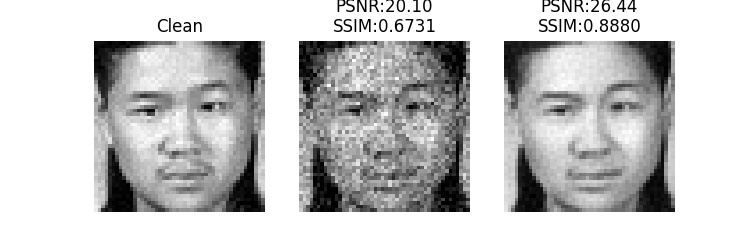

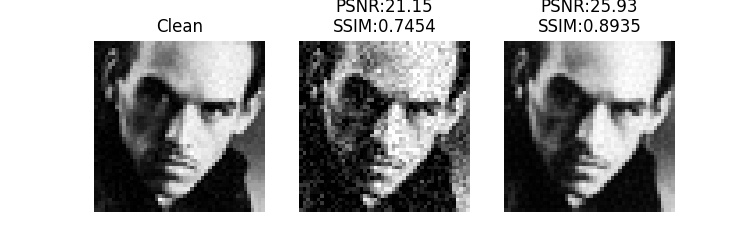

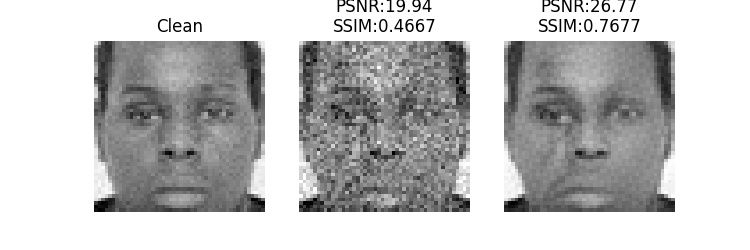

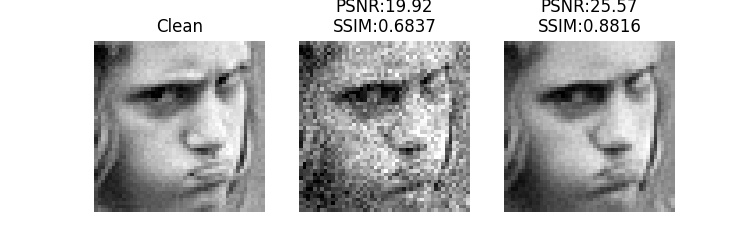

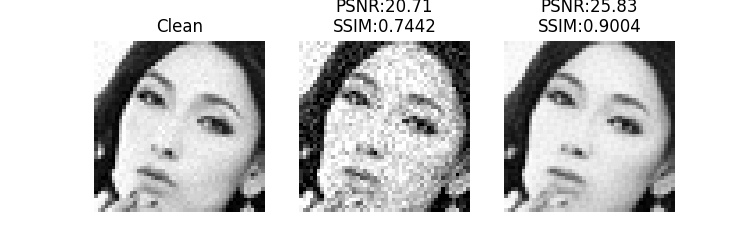


📊 Test Results (Full Set, 2148 samples):
  Loss: 0.114467
  Avg. Inference Time: 0.67 ms/image
  PSNR - Noisy vs Clean: 20.26 dB
  PSNR - Noisy vs Denoised: 22.22 dB
  PSNR - Clean vs Denoised: 26.23 dB
  SSIM - Noisy vs Clean: 0.6257
  SSIM - Noisy vs Denoised: 0.7326
  SSIM - Clean vs Denoised: 0.8399


In [34]:
import os
import time
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image as PILImage
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from IPython.display import display, Image
import torch
import torch.nn as nn
from piq import ssim  # function-based SSIM

# ✅ Directories for outputs
output_dir = './output_samples'
checkpoint_dir = './bimsaae_checkpoints'
os.makedirs(output_dir, exist_ok=True)
os.makedirs(checkpoint_dir, exist_ok=True)

# ✅ Save final model
final_model_path = os.path.join(checkpoint_dir, 'bimsaae_final.pth')
torch.save(model.state_dict(), final_model_path)
print(f"✅ Training complete. Final model saved to: {final_model_path}")

# ✅ Wrap SSIM as a function for compatibility
def ssim_criterion(x, y):
    return 1 - ssim(x, y, data_range=1.0, reduction='mean')

# Initialize metrics
test_loss = 0.0
inference_times = []
psnr_noisy_clean, psnr_noisy_denoised, psnr_clean_denoised = [], [], []
ssim_noisy_clean, ssim_noisy_denoised, ssim_clean_denoised = [], [], []
sample_images = []
num_samples = 5

# === Evaluate on 5 random samples ===
model.eval()
with torch.no_grad():
    test_samples = random.sample(list(test_dataset), min(num_samples, len(test_dataset)))
    for idx, (noisy, clean, noisy_path) in enumerate(test_samples):
        noisy, clean = noisy.unsqueeze(0).to(device), clean.unsqueeze(0).to(device)
        start_time = time.time()
        denoised = model(noisy)
        inference_times.append((time.time() - start_time) * 1000)  # ms

        # Compute combined loss
        mse_loss = nn.MSELoss()(denoised, clean)
        perceptual_loss = perceptual_criterion(denoised, clean)
        ssim_loss = ssim_criterion(denoised, clean)
        edge_loss = edge_criterion(denoised, clean)
        loss = 0.5*mse_loss + 0.3*perceptual_loss + 0.1*ssim_loss + 0.1*edge_loss
        test_loss += loss.item()

        # Convert tensors to numpy arrays
        noisy_np = np.clip(noisy.cpu().numpy()[0, 0], 0, 1).astype(np.float32)
        clean_np = np.clip(clean.cpu().numpy()[0, 0], 0, 1).astype(np.float32)
        denoised_np = np.clip(denoised.cpu().numpy()[0, 0], 0, 1).astype(np.float32)

        sample_images.append((clean_np, noisy_np, denoised_np, os.path.basename(noisy_path)))

        # PSNR & SSIM
        psnr_nc = peak_signal_noise_ratio(clean_np, noisy_np, data_range=1.0)
        psnr_nd = peak_signal_noise_ratio(noisy_np, denoised_np, data_range=1.0)
        psnr_cd = peak_signal_noise_ratio(clean_np, denoised_np, data_range=1.0)

        ssim_nc = structural_similarity(clean_np, noisy_np, data_range=1.0, win_size=7)
        ssim_nd = structural_similarity(noisy_np, denoised_np, data_range=1.0, win_size=7)
        ssim_cd = structural_similarity(clean_np, denoised_np, data_range=1.0, win_size=7)

        psnr_noisy_clean.append(psnr_nc)
        psnr_noisy_denoised.append(psnr_nd)
        psnr_clean_denoised.append(psnr_cd)
        ssim_noisy_clean.append(ssim_nc)
        ssim_noisy_denoised.append(ssim_nd)
        ssim_clean_denoised.append(ssim_cd)

        # Plot and save
        fig, axes = plt.subplots(1, 3, figsize=(7.5, 2.5))
        axes[0].imshow(clean_np, cmap='gray'); axes[0].set_title("Clean"); axes[0].axis('off')
        axes[1].imshow(noisy_np, cmap='gray'); axes[1].set_title(f"Noisy\nPSNR:{psnr_nc:.2f}\nSSIM:{ssim_nc:.4f}"); axes[1].axis('off')
        axes[2].imshow(denoised_np, cmap='gray'); axes[2].set_title(f"Denoised\nPSNR:{psnr_cd:.2f}\nSSIM:{ssim_cd:.4f}"); axes[2].axis('off')

        canvas = FigureCanvas(fig)
        canvas.draw()
        buf, (w, h) = canvas.print_to_buffer()
        img = np.frombuffer(buf, dtype=np.uint8).reshape(h, w, 4)[:, :, :3]
        pil_img = PILImage.fromarray(img)
        sample_path = os.path.join(output_dir, f'sample_{idx+1}.jpg')
        pil_img.save(sample_path, quality=95)
        plt.close(fig)

        display(Image(filename=sample_path))

# === Evaluate on entire test set ===
test_loss_total = 0.0
total_samples = 0
test_psnr_nc, test_psnr_nd, test_psnr_cd = 0.0, 0.0, 0.0
test_ssim_nc, test_ssim_nd, test_ssim_cd = 0.0, 0.0, 0.0
inference_times_full = []

with torch.no_grad():
    for noisy, clean, _ in test_loader:
        noisy, clean = noisy.to(device), clean.to(device)
        start_time = time.time()
        denoised = model(noisy)
        inf_time = (time.time() - start_time) * 1000 / noisy.size(0)
        inference_times_full.append(inf_time)

        mse_loss = nn.MSELoss()(denoised, clean)
        perceptual_loss = perceptual_criterion(denoised, clean)
        ssim_loss = ssim_criterion(denoised, clean)
        edge_loss = edge_criterion(denoised, clean)
        loss = 0.5*mse_loss + 0.3*perceptual_loss + 0.1*ssim_loss + 0.1*edge_loss
        test_loss_total += loss.item() * noisy.size(0)

        noisy_np = noisy.cpu().numpy()
        clean_np = clean.cpu().numpy()
        denoised_np = denoised.cpu().numpy()

        for i in range(noisy_np.shape[0]):
            nc = peak_signal_noise_ratio(clean_np[i,0], noisy_np[i,0], data_range=1.0)
            nd = peak_signal_noise_ratio(noisy_np[i,0], denoised_np[i,0], data_range=1.0)
            cd = peak_signal_noise_ratio(clean_np[i,0], denoised_np[i,0], data_range=1.0)

            s_nc = structural_similarity(clean_np[i,0], noisy_np[i,0], data_range=1.0, win_size=7)
            s_nd = structural_similarity(noisy_np[i,0], denoised_np[i,0], data_range=1.0, win_size=7)
            s_cd = structural_similarity(clean_np[i,0], denoised_np[i,0], data_range=1.0, win_size=7)

            test_psnr_nc += nc
            test_psnr_nd += nd
            test_psnr_cd += cd
            test_ssim_nc += s_nc
            test_ssim_nd += s_nd
            test_ssim_cd += s_cd
            total_samples += 1

# Print final metrics
test_loss_total /= len(test_dataset)
test_psnr_nc /= total_samples
test_psnr_nd /= total_samples
test_psnr_cd /= total_samples
test_ssim_nc /= total_samples
test_ssim_nd /= total_samples
test_ssim_cd /= total_samples

print(f"\n📊 Test Results (Full Set, {total_samples} samples):")
print(f"  Loss: {test_loss_total:.6f}")
print(f"  Avg. Inference Time: {np.mean(inference_times_full):.2f} ms/image")
print(f"  PSNR - Noisy vs Clean: {test_psnr_nc:.2f} dB")
print(f"  PSNR - Noisy vs Denoised: {test_psnr_nd:.2f} dB")
print(f"  PSNR - Clean vs Denoised: {test_psnr_cd:.2f} dB")
print(f"  SSIM - Noisy vs Clean: {test_ssim_nc:.4f}")
print(f"  SSIM - Noisy vs Denoised: {test_ssim_nd:.4f}")
print(f"  SSIM - Clean vs Denoised: {test_ssim_cd:.4f}")

✅ Training complete. Final model saved to: ./bimsaae_checkpoints/bimsaae_final.pth


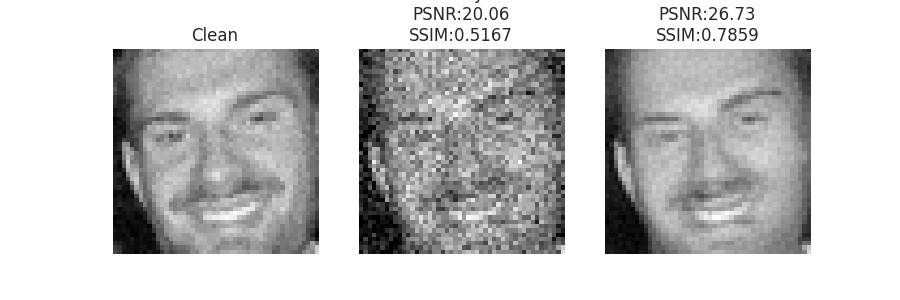

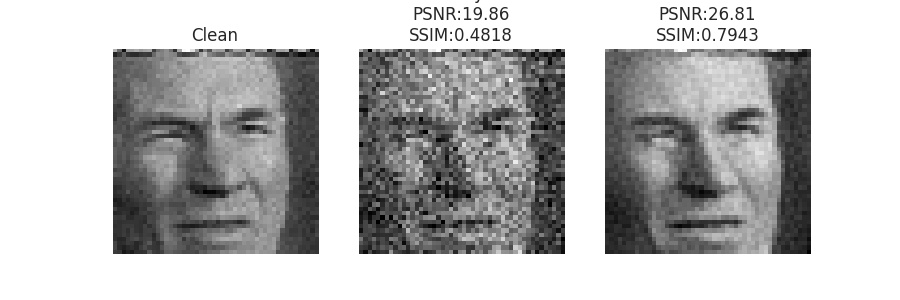

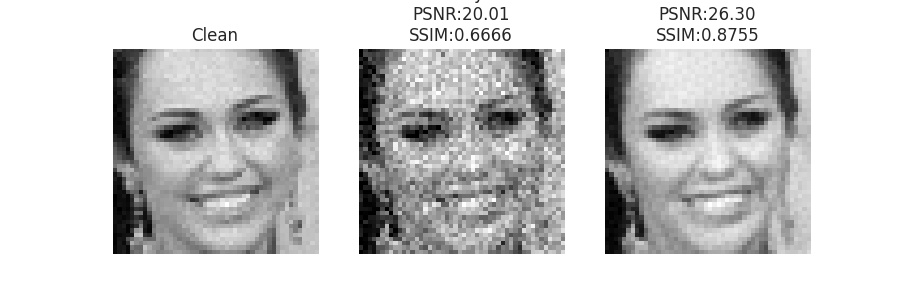

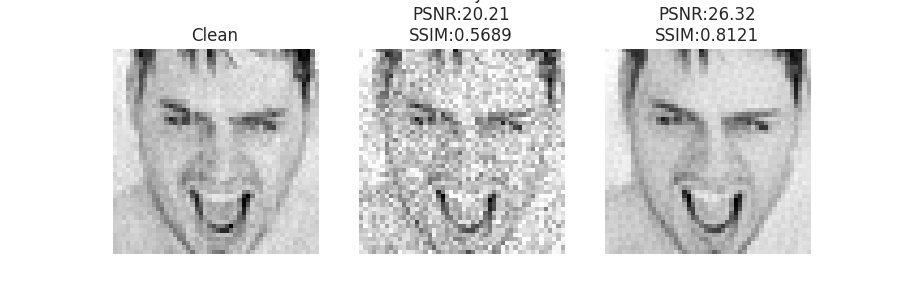

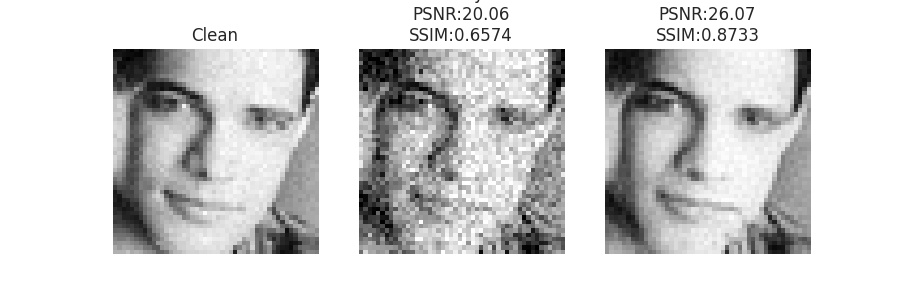

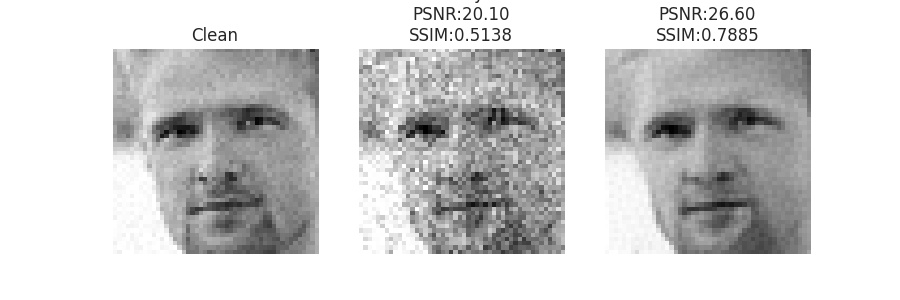

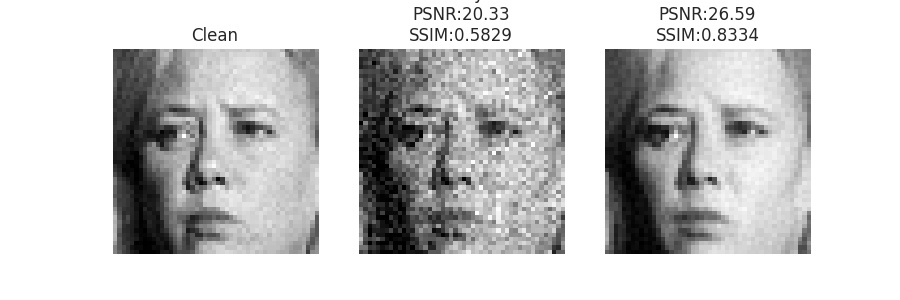

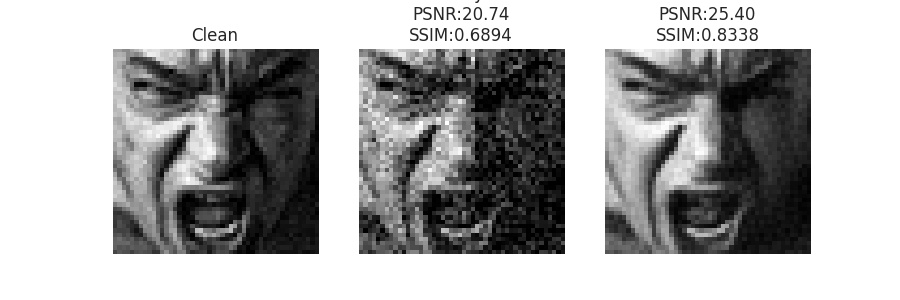

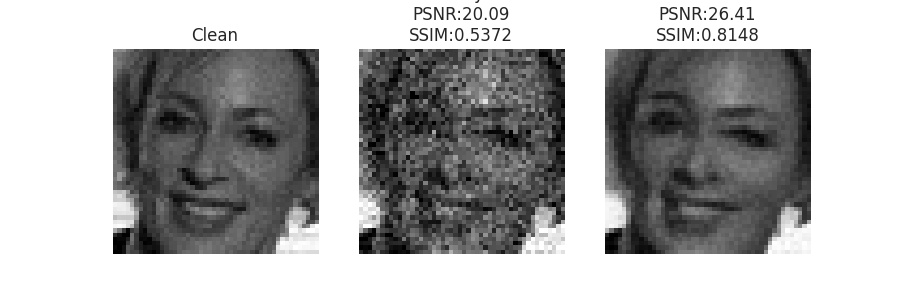

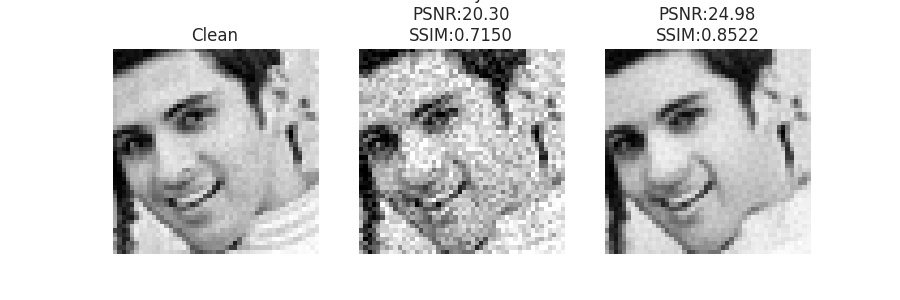

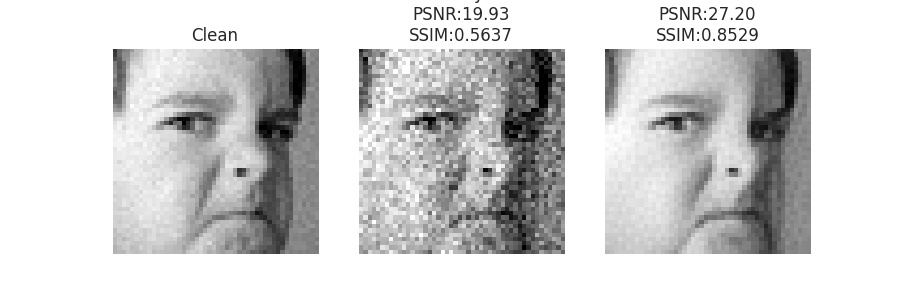

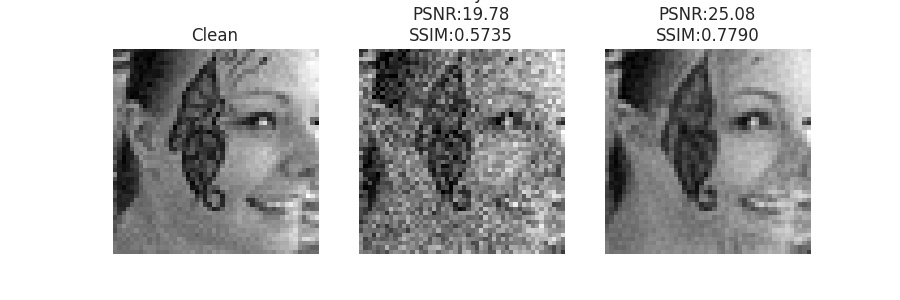

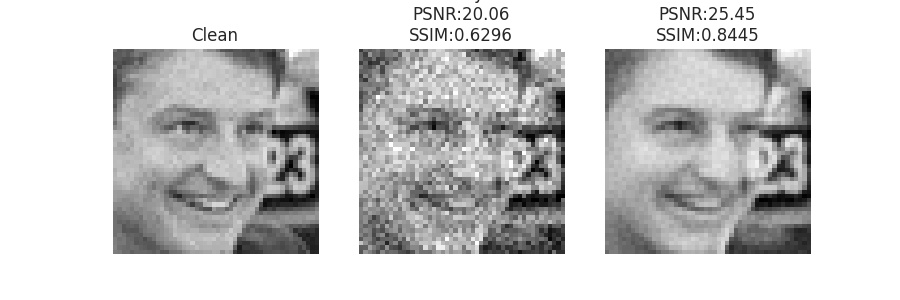

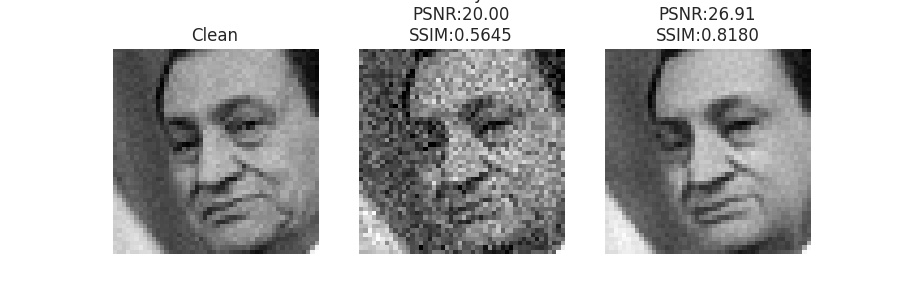

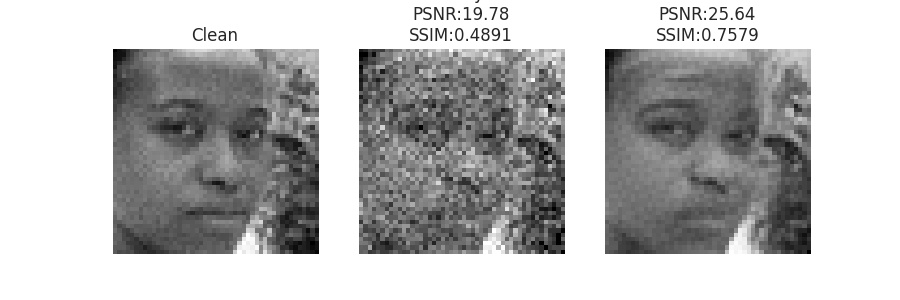


📊 Aggregate Results (15 Samples)
  Avg PSNR - Noisy vs Clean: 20.09 dB
  Avg PSNR - Noisy vs Denoised: 21.98 dB
  Avg PSNR - Clean vs Denoised: 26.16 dB
  Avg SSIM - Noisy vs Clean: 0.5833
  Avg SSIM - Noisy vs Denoised: 0.7016
  Avg SSIM - Clean vs Denoised: 0.8211
  Avg MSE - Clean vs Denoised: 0.002448
  Avg Inference Time: 4.62 ms
  Avg Test Loss: 0.117711


In [36]:
import os
import time
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image as PILImage
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from IPython.display import display, Image
import torch
import torch.nn as nn
from piq import ssim  # function-based SSIM

# ===== Directories for outputs =====
output_dir = './output_samples'
checkpoint_dir = './bimsaae_checkpoints'
os.makedirs(output_dir, exist_ok=True)
os.makedirs(checkpoint_dir, exist_ok=True)

# ===== Save final model =====
final_model_path = os.path.join(checkpoint_dir, 'bimsaae_final.pth')
torch.save(model.state_dict(), final_model_path)
print(f"✅ Training complete. Final model saved to: {final_model_path}")

# ===== SSIM wrapper function =====
def ssim_criterion(x, y):
    return 1 - ssim(x, y, data_range=1.0, reduction='mean')

# ===== Initialize metrics as lists =====
test_loss = 0.0
inference_times = []
psnr_noisy_clean, psnr_noisy_denoised, psnr_clean_denoised = [], [], []
ssim_noisy_clean, ssim_noisy_denoised, ssim_clean_denoised = [], [], []
mse_values = []
sample_images = []

# ===== Number of samples to visualize =====
num_samples = 15

# ===== Evaluate on 15 random samples =====
model.eval()
with torch.no_grad():
    test_samples = random.sample(list(test_dataset), min(num_samples, len(test_dataset)))

    for idx, (noisy, clean, noisy_path) in enumerate(test_samples):
        noisy, clean = noisy.unsqueeze(0).to(device), clean.unsqueeze(0).to(device)

        # ===== Inference =====
        start_time = time.time()
        denoised = model(noisy)
        inference_times.append((time.time() - start_time) * 1000)  # ms

        # ===== Compute combined loss =====
        mse_loss = nn.MSELoss()(denoised, clean)
        perceptual_loss_val = perceptual_criterion(denoised, clean)
        ssim_loss_val = ssim_criterion(denoised, clean)
        edge_loss_val = edge_criterion(denoised, clean)
        loss = 0.5*mse_loss + 0.3*perceptual_loss_val + 0.1*ssim_loss_val + 0.1*edge_loss_val
        test_loss += loss.item()

        # ===== Convert tensors to numpy arrays =====
        # Check if grayscale (1 channel) or RGB (3 channels)
        channels = noisy.shape[1]
        if channels == 1:
            noisy_np = np.clip(noisy.cpu().numpy()[0,0], 0, 1).astype(np.float32)
            clean_np = np.clip(clean.cpu().numpy()[0,0], 0, 1).astype(np.float32)
            denoised_np = np.clip(denoised.cpu().numpy()[0,0], 0, 1).astype(np.float32)
        else:  # RGB
            noisy_np = np.clip(noisy.cpu().numpy()[0].transpose(1,2,0), 0, 1).astype(np.float32)
            clean_np = np.clip(clean.cpu().numpy()[0].transpose(1,2,0), 0, 1).astype(np.float32)
            denoised_np = np.clip(denoised.cpu().numpy()[0].transpose(1,2,0), 0, 1).astype(np.float32)

        sample_images.append((clean_np, noisy_np, denoised_np, os.path.basename(noisy_path)))

        # ===== PSNR & SSIM =====
        psnr_nc = peak_signal_noise_ratio(clean_np, noisy_np, data_range=1.0)
        psnr_nd = peak_signal_noise_ratio(noisy_np, denoised_np, data_range=1.0)
        psnr_cd = peak_signal_noise_ratio(clean_np, denoised_np, data_range=1.0)

        ssim_nc = structural_similarity(clean_np, noisy_np, data_range=1.0, win_size=7)
        ssim_nd = structural_similarity(noisy_np, denoised_np, data_range=1.0, win_size=7)
        ssim_cd = structural_similarity(clean_np, denoised_np, data_range=1.0, win_size=7)

        psnr_noisy_clean.append(psnr_nc)
        psnr_noisy_denoised.append(psnr_nd)
        psnr_clean_denoised.append(psnr_cd)
        ssim_noisy_clean.append(ssim_nc)
        ssim_noisy_denoised.append(ssim_nd)
        ssim_clean_denoised.append(ssim_cd)

        mse_values.append(np.mean((clean_np - denoised_np)**2))

        # ===== Plot & save =====
        fig, axes = plt.subplots(1, 3, figsize=(9, 3))
        axes[0].imshow(clean_np, cmap='gray' if channels==1 else None)
        axes[0].set_title("Clean"); axes[0].axis('off')
        axes[1].imshow(noisy_np, cmap='gray' if channels==1 else None)
        axes[1].set_title(f"Noisy\nPSNR:{psnr_nc:.2f}\nSSIM:{ssim_nc:.4f}"); axes[1].axis('off')
        axes[2].imshow(denoised_np, cmap='gray' if channels==1 else None)
        axes[2].set_title(f"Denoised\nPSNR:{psnr_cd:.2f}\nSSIM:{ssim_cd:.4f}"); axes[2].axis('off')

        canvas = FigureCanvas(fig)
        canvas.draw()
        buf, (w, h) = canvas.print_to_buffer()
        img = np.frombuffer(buf, dtype=np.uint8).reshape(h, w, 4)[:, :, :3]
        pil_img = PILImage.fromarray(img)
        sample_path = os.path.join(output_dir, f'sample_{idx+1}.jpg')
        pil_img.save(sample_path, quality=95)
        plt.close(fig)

        display(Image(filename=sample_path))

# ===== Aggregate Metrics =====
print("\n📊 Aggregate Results (15 Samples)")
print(f"  Avg PSNR - Noisy vs Clean: {np.mean(psnr_noisy_clean):.2f} dB")
print(f"  Avg PSNR - Noisy vs Denoised: {np.mean(psnr_noisy_denoised):.2f} dB")
print(f"  Avg PSNR - Clean vs Denoised: {np.mean(psnr_clean_denoised):.2f} dB")
print(f"  Avg SSIM - Noisy vs Clean: {np.mean(ssim_noisy_clean):.4f}")
print(f"  Avg SSIM - Noisy vs Denoised: {np.mean(ssim_noisy_denoised):.4f}")
print(f"  Avg SSIM - Clean vs Denoised: {np.mean(ssim_clean_denoised):.4f}")
print(f"  Avg MSE - Clean vs Denoised: {np.mean(mse_values):.6f}")
print(f"  Avg Inference Time: {np.mean(inference_times):.2f} ms")
print(f"  Avg Test Loss: {test_loss/num_samples:.6f}")